# Debugging Notebook for functions

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from encoding import *
from processing import *
from decoding import *
from visualize import *
from mesh import *
import numpy as np
import matplotlib.pyplot as plt

# Loading data from mnist set
Functions in encoding.py

1
Number of '7' in this set: 47, number of '1' in this set: 53


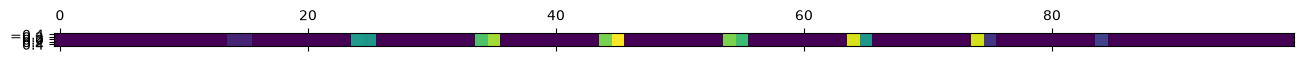

In [3]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = 100 #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = False #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

X, Y = get_data(values, mode, number, m, theta, norm_energy, seed) #X are the flattened arrays of the encoded mnist images, 
                                                                  #Y are the referring labels
#Example of the first entry
plt.matshow(np.real(X[0]).reshape(1, -1)) #reshaping it just for plotting with plt.matshow
print(Y[0])

print("Number of '7' in this set: " + str(np.sum(Y == 7))+", number of '1' in this set: " + str(np.sum(Y == 1)))


# Initializing MZI-Mesh
Functions in mesh.py
(No parameter initialization yet)

Number of layers in the setup: 4
MZIs along the layers in the setup: [2, 1, 2, 1]
Total number of (trainable) MZIs in the setup: 6


<Axes: title={'center': 'N=4, 4 Layer, 6 MZIs'}, xlabel='Layer', ylabel='Channel'>

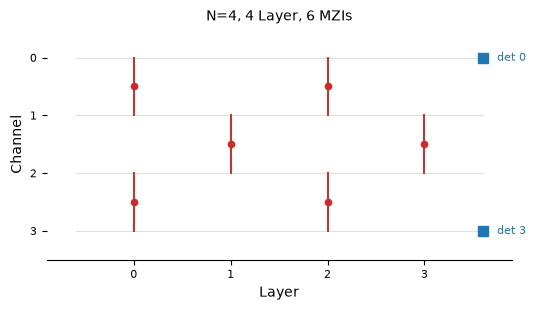

In [4]:
N=4 #Number of channels
L=4 #Number of layers
test_plan = plan_rectangular(N, L) #other plans are plan_redundant and plan_triangular
test_mesh = MZIMesh(N, test_plan) #Object containing the geometry of the MZI-Mesh

#Each mesh object carries its properties:
n_layers = test_mesh.n_layers
n_slots = test_mesh.slot_counts
n_mzis = test_mesh.n_mzis
print(f"Number of layers in the setup: {n_layers}") #layers of setup
print(f"MZIs along the layers in the setup: {n_slots}") #distribution of MZIs along the layers
print(f"Total number of (trainable) MZIs in the setup: {n_mzis}") #number of (trainable MZIs in this setup)


plot_mesh(test_mesh, color_by=None, detectors=[0, 3], label_step=None) #function of visualize.py to show the geometry (and detectors)



# Initializing parameters

In [35]:
phis, thetas = test_mesh.init_random()
print(f"Phis: {phis}")
print(f"Thetas: {thetas}")


Phis: [array([1.00492957, 2.84242261]), array([2.89786089]), array([2.72587348, 0.95132579]), array([1.73070536])]
Thetas: [array([4.25831593, 1.75040267]), array([5.80091581]), array([1.44310258, 5.96068077]), array([0.83869458])]


In [ ]:

thetas, phis = mesh.init_haar(rng)
batch = rng.normal(size=(N, 5)) + 1j*rng.normal(size=(N, 5))
out = mesh.forward(batch, thetas, phis)
print("Batch:", batch.shape, "->", out.shape,
        " Energie pro Sample erhalten:",
        np.allclose(np.sum(np.abs(out)**2, axis=0),
                    np.sum(np.abs(batch)**2, axis=0)))

NameError: name 'rng' is not defined

[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 0. 1. 0. 1.]]


C:\Users\tim\AppData\Local\Temp\ipykernel_46944\2539130067.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


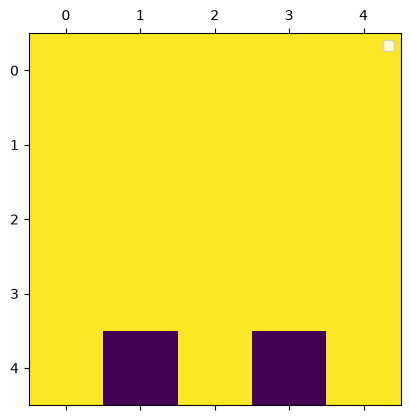

In [ ]:
a=np.ones((5,5))
a[-1, 1::2] = 0

plt.matshow(a)
plt.legend()
print(a)

In [ ]:
a=set_random_weights(3,3)


C:\Users\tim\AppData\Local\Temp\ipykernel_46944\2858483774.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(667.8365885416666, 0.5, 'Intensity')

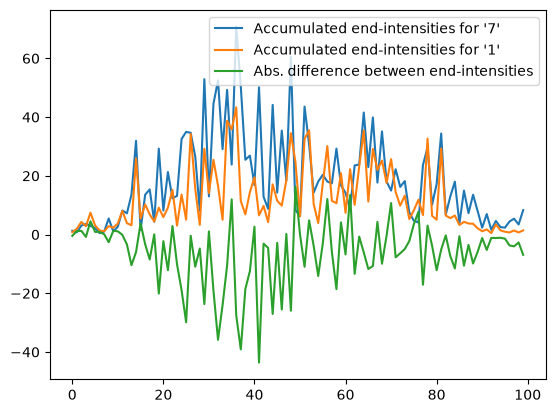

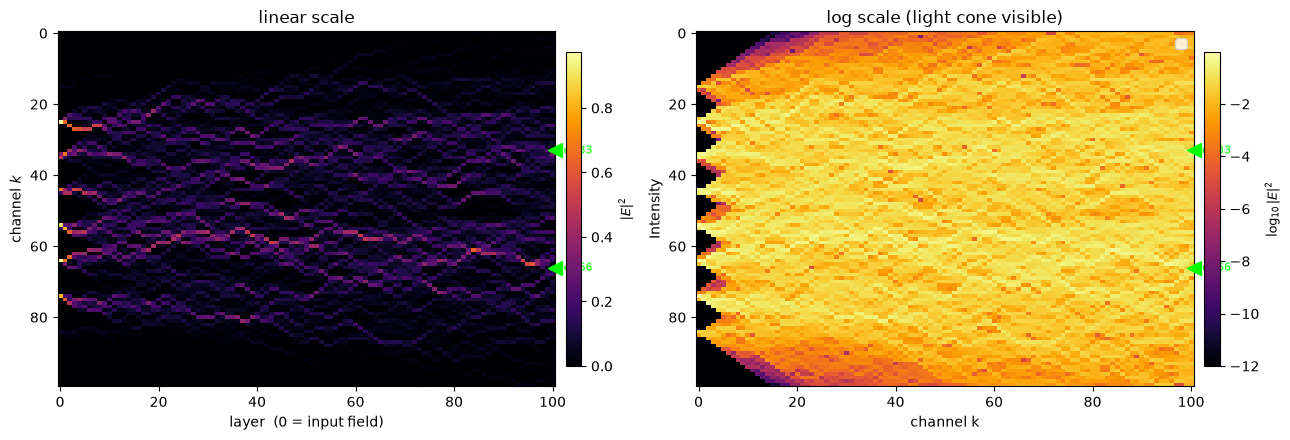

In [ ]:
# --- Intensitaets-Plot, realistisches Mesh N=100 ---
N2, L2 = 100, 100
number=300
p2 = set_random_weights(L2, N2 // 2)
E, y = get_data(np.array([7]), mode="Test", number=number, m=10, theta=1, normalize_energy=False)
I_end_7=np.zeros((100))
for z in range(number):
    I=np.abs(forward_all_layers_with_history(E[z], p2))**2
    I_end_7+=I[-1,:]
plt.plot(I_end_7, label="Accumulated end-intensities for '7'")

E, y = get_data(np.array([1]), mode="Test", number=number, m=10, theta=1, normalize_energy=False)
I_end_1=np.zeros((100))
for z in range(number):
    I=np.abs(forward_all_layers_with_history(E[z], p2))**2
    I_end_1+=I[-1,:]
plt.plot(I_end_1, label="Accumulated end-intensities for '1'")

diffI_7_to_I_1 = I_end_1-I_end_7

plt.plot((diffI_7_to_I_1), label="Abs. difference between end-intensities")
plt.legend()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_intensity_map(I, detectors=[33, 66], ax=axes[0],#
                    title="linear scale")
plot_intensity_map(I, detectors=[33, 66], ax=axes[1], log=True,
                    title="log scale (light cone visible)")
fig.tight_layout()
plt.legend()
plt.xlabel("channel k")
plt.ylabel("Intensity")


(13007, 28, 28)
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  124 253 255  63   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  96
  244 251 253  62   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 127
  251 251 253  62   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   